In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/ecommerce_data.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')
print('Data Loaded!')
df.head()

Data Loaded!


,order_id,customer_id,order_date,product,category,quantity,unit_price,revenue,region,status,order_month
0,1001,C001,2024-01-05,Laptop,Electronics,1,55000,55000,North,Completed,2024-01
1,1002,C002,2024-01-07,T-Shirt,Clothing,3,499,1497,South,Completed,2024-01
2,1003,C003,2024-01-10,Headphones,Electronics,2,2999,5998,East,Completed,2024-01
3,1004,C001,2024-01-15,Mouse,Electronics,1,799,799,North,Completed,2024-01
4,1005,C004,2024-01-18,Jeans,Clothing,2,1299,2598,West,Completed,2024-01


In [4]:
# =============================================
# COHORT ANALYSIS
# =============================================

# Step 1: Get cohort (first purchase month per customer)
df['cohort_month'] = df.groupby('customer_id')['order_month'].transform('min')

# Step 2: Calculate cohort index (months since first purchase)
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Step 3: Count unique customers in each cohort/index
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

# Step 4: Retention rates
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print('Cohort Table (Retention %):')
print(retention.round(1))

Cohort Table (Retention %):
cohort_index     0      1      2     3     4     5     10
cohort_month                                             
2024-01       100.0   57.1   42.9  28.6  14.3  14.3  14.3
2024-02       100.0   40.0   40.0  20.0   NaN   NaN   NaN
2024-03       100.0    NaN   75.0  25.0   NaN   NaN   NaN
2024-04       100.0    NaN   50.0  50.0   NaN   NaN   NaN
2024-05       100.0    NaN   40.0  40.0   NaN   NaN   NaN
2024-06       100.0    NaN   66.7  33.3   NaN   NaN   NaN
2024-07       100.0    NaN   50.0  50.0   NaN   NaN   NaN
2024-08       100.0    NaN  100.0   NaN   NaN   NaN   NaN
2024-09       100.0   50.0   50.0   NaN   NaN   NaN   NaN
2024-11       100.0  100.0    NaN   NaN   NaN   NaN   NaN
2024-12       100.0    NaN    NaN   NaN   NaN   NaN   NaN


In [6]:
import os
os.makedirs('dashboard', exist_ok=True)

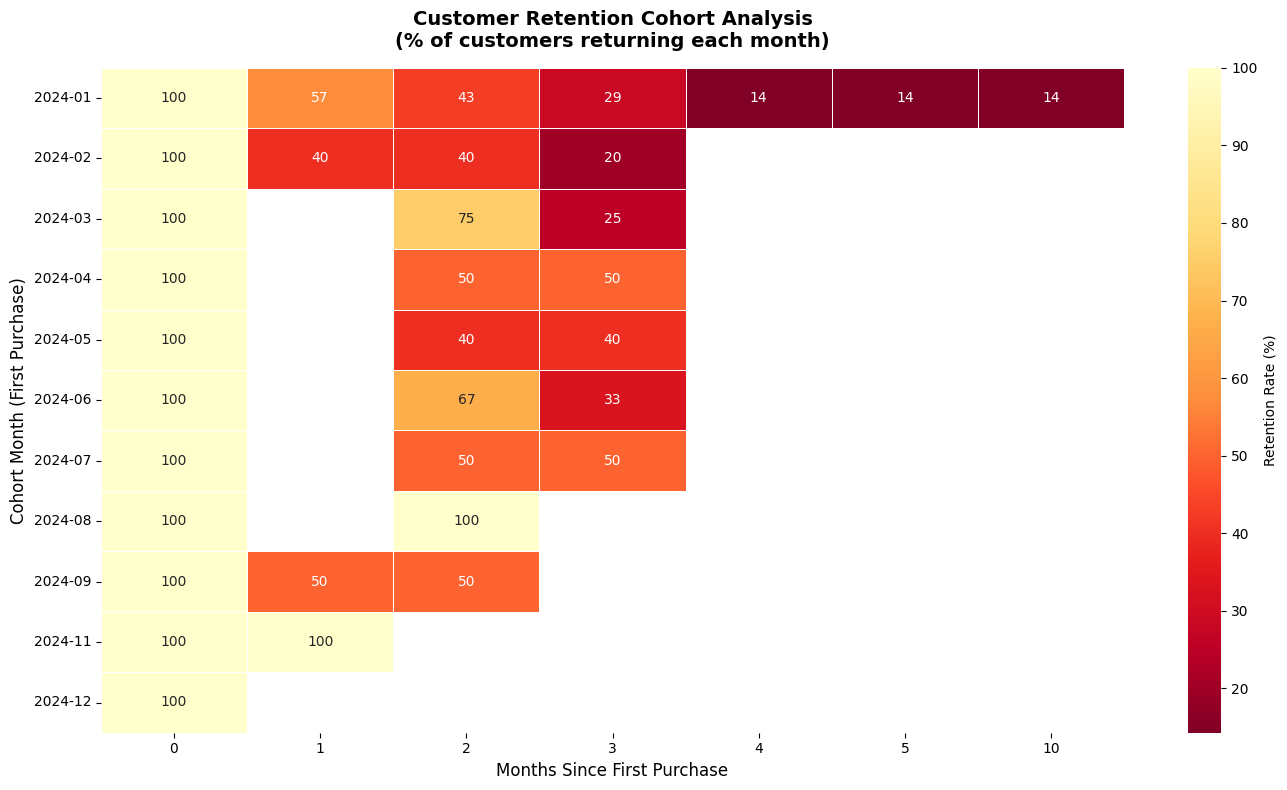

Cohort Heatmap saved!


In [7]:
# VISUALIZE COHORT HEATMAP
# =============================================
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title('Customer Retention Cohort Analysis\n(% of customers returning each month)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month (First Purchase)', fontsize=12)

plt.tight_layout()
plt.savefig('dashboard/cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cohort Heatmap saved!')

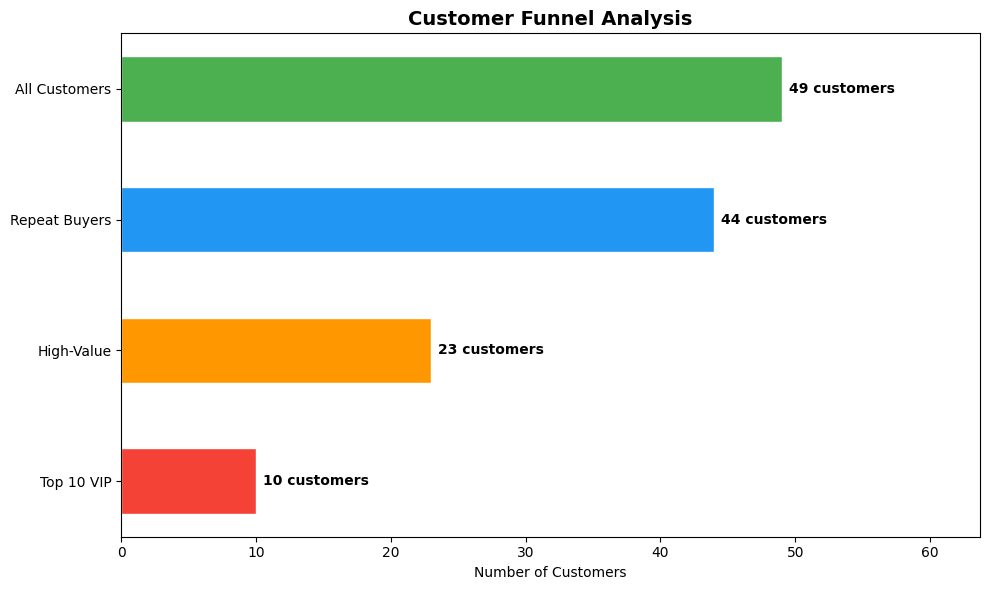

Funnel Analysis saved!


In [9]:
# =============================================
# FUNNEL ANALYSIS
# =============================================
total_customers = df['customer_id'].nunique()
repeat_customers = df[df.groupby('customer_id')['order_id'].transform('count') > 1]['customer_id'].nunique()
high_value = df[df['revenue'] > df['revenue'].quantile(0.75)]['customer_id'].nunique()
top_customers = df.groupby('customer_id')['revenue'].sum().nlargest(10).index
loyal_customers = len(top_customers)

stages = ['All Customers', 'Repeat Buyers', 'High-Value', 'Top 10 VIP']
counts  = [total_customers, repeat_customers, high_value, loyal_customers]
colors  = ['#4CAF50','#2196F3','#FF9800','#F44336']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1], edgecolor='white', height=0.5)

for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{count} customers', va='center', fontweight='bold')

ax.set_title('Customer Funnel Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.set_xlim(0, max(counts) * 1.3)
plt.tight_layout()
plt.savefig('dashboard/funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Funnel Analysis saved!')